In [28]:
import numpy as np

from math import pi, sin, cos, sqrt, tanh

from siltsong import spherical_to_cartesian, cartesian_to_spherical, plot_density_powernorm, radiative_transfer
from siltsong.dust import mrn, thermal_emission, henyey_greenstein
from siltsong.stars import blackbody

In [29]:
view_length = 2000
distance_steps = 200
theta_steps = 360
phi_steps = 360
distance_substeps = 10

resolution = 201
depth = 201
depth_substeps = 10
dw = view_length / depth
ds_depth = dw / depth_substeps
grid_size = view_length / resolution

inclination_degrees = 0
inclination = pi * (inclination_degrees / 180)
sin_inc = sin(inclination)
cos_inc = cos(inclination)

ms_count = 1e5

wavelength = 1e-4

In [30]:
central_source = blackbody(wavelength, temperature = 2500)
    
sca_cm_squared_per_g, ext_cm_squared_per_g = 1, 1

source_function = blackbody(wavelength, temperature = 800)

def scattering_phase_function(angle):
    return 1 / (4 * pi)

In [31]:
def density_spherical(r, theta):

    p = 2
    Y = 1000
    
    tau_1 = 1000
    r1 = 1 / ((sca_cm_squared_per_g + ext_cm_squared_per_g) * (1 - 1 / Y))
    r2 = r1 * Y

    if r >= r1 and r <= r2:
        y = r / r1
        return y ** (-p)
    else:
        return 0

def density_cartesian(x, y, z):
    r, theta, _ = cartesian_to_spherical(x, y, z)
    return density_spherical(r, theta)

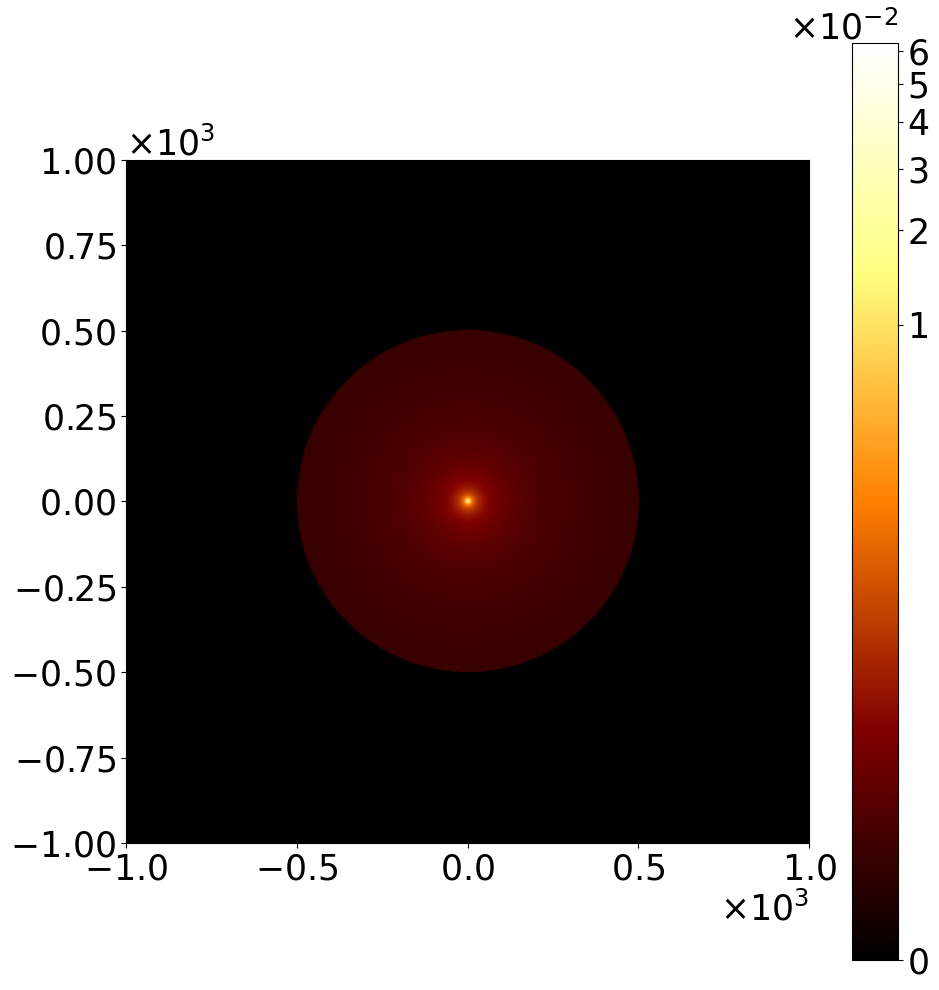

In [32]:
plot_density_powernorm(density_cartesian, view_length, power = 0.2, units = 'None')

In [33]:
image = radiative_transfer(view_length, inclination_degrees, resolution, 
                           central_source, 
                           density_spherical, density_cartesian, 
                           sca_cm_squared_per_g, ext_cm_squared_per_g, source_function, scattering_phase_function, 
                           depth, depth_substeps, distance_steps, distance_substeps, theta_steps, phi_steps, 
                           ms_count, axisymmetry = True, reflection_symmetry = True)

Sending photons from the central source(s). 
Tracing single scattered photons: 


100%|█████████████████████████████████████████| 360/360 [01:02<00:00,  5.81it/s]


Tracing multiple scattered photons: 


100%|█████████████████████████████████| 100000/100000 [00:59<00:00, 1686.33it/s]


Performing peel-off: 


100%|█████████████████████████████████████████| 201/201 [00:22<00:00,  8.90it/s]


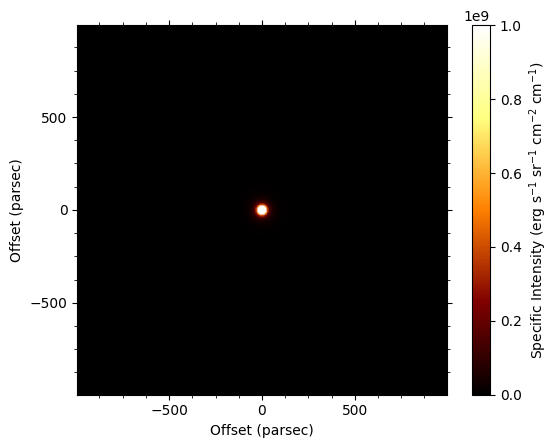

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import MultipleLocator

pixel_size = view_length / resolution
n_pixels = image.shape[0]
half_size = (n_pixels // 2) * pixel_size
extent = [-half_size, half_size, -half_size, half_size]

plt.imshow(image, origin = 'lower', cmap = 'afmhot', extent = extent, vmin = 0, vmax = 1e9)

ax = plt.gca()
ax.set_aspect('equal')
ax.xaxis.set_major_locator(MultipleLocator(view_length // 4))
ax.xaxis.set_minor_locator(MultipleLocator(view_length // 16))
ax.yaxis.set_major_locator(MultipleLocator(view_length // 4))
ax.yaxis.set_minor_locator(MultipleLocator(view_length // 16))
ax.tick_params(which = 'both', direction = 'out', top = True, right = True)

ax.set_xlabel('Offset (parsec)')
ax.set_ylabel('Offset (parsec)')

cbar = plt.colorbar()
cbar.set_label(r'Specific Intensity (erg s$^{{-1}}$ sr$^{{-1}}$ cm$^{{-2}}$ cm$^{{-1}}$)')

plt.show()

In [35]:
# END